In [1]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
!unzip fruits.zip

'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [4]:
tf.__version__

'2.19.0'

In [5]:
img_height, img_width = 32, 32
batch_size = 20

train_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\anish\Data Science with Gen AI\Class Codes\multi class classification\fruits\fruits\train",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\anish\Data Science with Gen AI\Class Codes\multi class classification\fruits\fruits\validation",
    image_size = (img_height, img_width),
    batch_size = batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\anish\Data Science with Gen AI\Class Codes\multi class classification\fruits\fruits\train",
    image_size = (img_height, img_width),
    batch_size = batch_size
)

Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 460 files belonging to 3 classes.


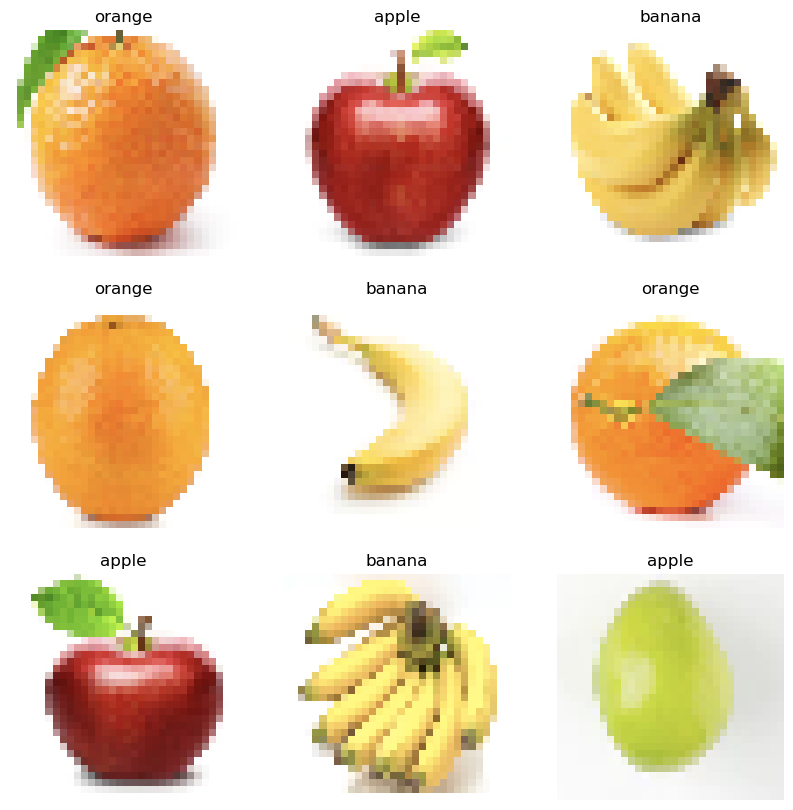

In [6]:
class_names = ["apple", "banana", "orange"]
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [7]:
model = tf.keras.Sequential(
    [
     tf.keras.layers.Rescaling(1./255),
     tf.keras.layers.Conv2D(32, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(64, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(128, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Flatten(),
     tf.keras.layers.Dense(128, activation="softmax"),
     tf.keras.layers.Dense(3)
    ]
)

In [8]:
model.compile(
    optimizer="rmsprop",
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics=['accuracy']
)

In [9]:
model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 100
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.3449 - loss: 1.0987 - val_accuracy: 0.3333 - val_loss: 1.0946
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.3647 - loss: 1.0870 - val_accuracy: 0.5000 - val_loss: 1.0358
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5187 - loss: 1.0327 - val_accuracy: 0.4091 - val_loss: 1.0585
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5855 - loss: 0.9863 - val_accuracy: 0.4848 - val_loss: 0.9932
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6509 - loss: 0.9658 - val_accuracy: 0.5606 - val_loss: 0.9593
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7258 - loss: 0.9341 - val_accuracy: 0.6667 - val_loss: 0.9364
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7905 - loss: 0.9097 - val_accuracy: 0.7424 - val_loss: 0.9099
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8194 - loss: 0.8903 - val_accuracy: 0.

In [10]:
model.evaluate(test_ds)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9965 - loss: 0.0420


[0.037284038960933685, 0.997826099395752]

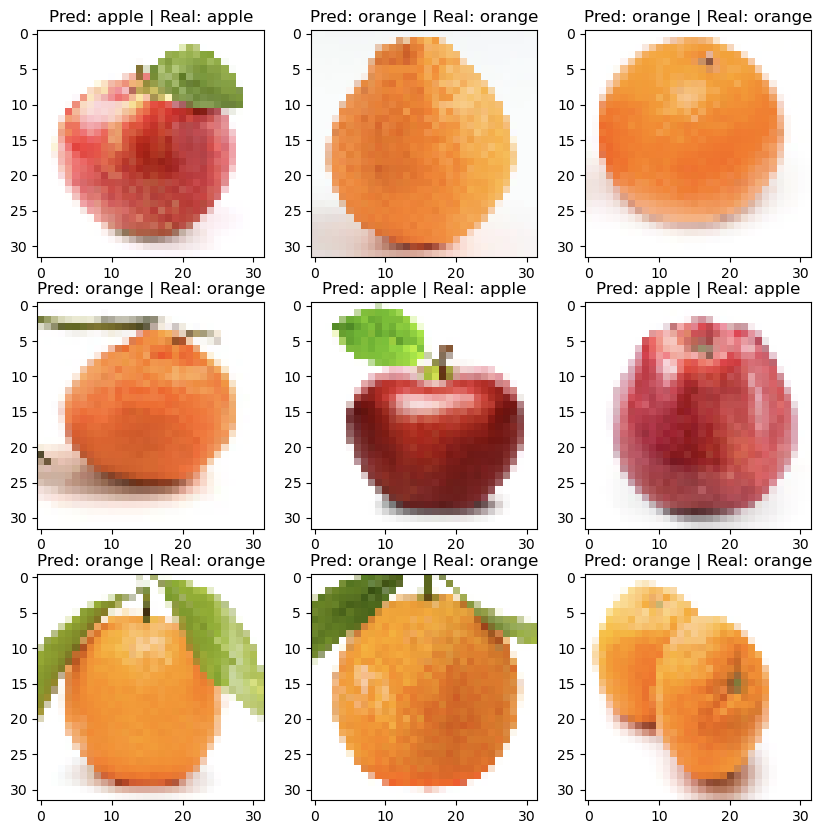

In [11]:
import numpy

plt.figure(figsize=(10,10))
for images, labels in test_ds.take(1):
  classifications = model(images)
  # print(classifications)

  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index = numpy.argmax(classifications[i])
    plt.title("Pred: " + class_names[index] + " | Real: " + class_names[labels[i]])

In [12]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", 'wb') as f:
  f.write(tflite_model)

INFO:tensorflow:Assets written to: C:\Users\anish\AppData\Local\Temp\tmpmzo32eqz\assets


INFO:tensorflow:Assets written to: C:\Users\anish\AppData\Local\Temp\tmpmzo32eqz\assets


Saved artifact at 'C:\Users\anish\AppData\Local\Temp\tmpmzo32eqz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2316200240016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2316200241744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2316200241552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2316200243088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2316200242704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2316200243664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2316200242512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2316200244624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2316182506768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2316200245584: TensorSpec(shape=(), dtype=tf.resource, name=None)
